# FIE463 – Numerical Methods in Macroeconomics and Finance  
## Term Paper 2

---
<div style="margin-top: 30px;">

**Candidate numbers:** XXX  
Norwegian School of Economics (NHH)

</div>
---

<div style="margin-top: 40px; font-size: 14px; color: gray;">
Artificial intelligence tools (ChatGPT, openAI) have been used for support in this assignment. The tool has been used for code clarification, debugging, and improving language and structure. All analysis, implementation, and final solutions are our own work.
</div>

# Part 1 — Data preprocessing (SCE)

## Importing packages

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import validation_curve, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import RidgeCV

## 1. Import and merge SCE data
Loading all files and combine them into a single dataset

In [2]:
files = glob.glob("data/sce_extract_*.csv")

df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True)

print(f"Total observations: {len(df)}")

Total observations: 180268


## 2. Forward fill variables

Some variables are only observed in the first survey wave, we therefpre forward-fill these variables within individuals 

In [3]:
df = df.sort_values(["userid", "date"])

#only filling individual characteristics
cols_to_fill = [
    "age_init", "female", "educ", "hh_inc_bin",
    "num_kids", "owner"
] 

df[cols_to_fill] = df.groupby("userid")[cols_to_fill].ffill()

## 3. Drop observations from 2025

We exclude observations from 2025 to avoid the volatility generated by the second Trump administration

In [4]:
# converting date to datetime
df["date"] = pd.to_datetime(df["date"])

before = len(df)

df = df[df["date"] < "2025-01-01"]

print(f"Dropped {before - len(df)} observations")

Dropped 4167 observations


## 4. Drop missing values

We remove observations with missing values for the selected variables

In [5]:
variables = [
    "infl_1y",
    "house_price_change",
    "prob_unrate_up",
    "prob_stocks_up"
]

before = len(df)

df = df.dropna(subset=variables)

after = len(df)

print(f"Observations before dropna: {before}")
print(f"Observations after dropna: {after}")
print(f"Dropped {before - after} observations (missing values)")


Observations before dropna: 176101
Observations after dropna: 174324
Dropped 1777 observations (missing values)


## 5. Removing outliers

Winsorizing extreme values by keeping observations between the 1st and 99th percentiles

In [6]:
# before trimming
before = len(df)

# create mask (true/false)
mask = pd.Series(True, index=df.index)

for var in variables:
    p1 = df[var].quantile(0.01)
    p99 = df[var].quantile(0.99)
    
    mask &= (df[var] > p1) & (df[var] < p99)

# apply mask
df = df[mask].copy()

# after trimming
after = len(df)

print(f"Observations before trimming: {before}")
print(f"Observations after trimming: {after}")
print(f"Dropped {before - after} observations (outliers)")

Observations before trimming: 174324
Observations after trimming: 159630
Dropped 14694 observations (outliers)


## 6. Creating indicator variables

Constructing binary indicators capturing optimism about unemployment, stocks, and house prices

In [7]:
df["optimist_unrate"] = (df["prob_unrate_up"] < 50).astype(int)
df["optimist_stocks"] = (df["prob_stocks_up"] > 50).astype(int)
df["optimist_house_price"] = (df["house_price_change"] > 0).astype(int)

## 7. Summary statistics

Reporting the key dataset characteristics after cleaning 

In [8]:
print(f"Observations: {len(df):,}")
print(f"Survey periods: {df['wid'].nunique():,}")

print(f"Start date: {df['date'].min().strftime('%Y-%m')}")
print(f"End date:   {df['date'].max().strftime('%Y-%m')}")

Observations: 159,630
Survey periods: 139
Start date: 2013-06
End date:   2024-12


# Part 2 — Data preprocessing (macro/finance)

In the second part, we augment the SCE dataset with macroeconomic and financial tdata from Yahoo Finance and FRED. To avoid look-ahead bias, we ensure that only information available at the time of each survey is used when merging the data. We then construct additional variables capturing changes in the data (e.g., monthly differences).


Note: the data from Yahoo finance was downloaded using the yfinance package

## Choice of macroeconomic variables

We include a set of macroeconomic and financial variables that capture key drivers of household expectations across financial markets, inflation, and the real economy.

The S&P 500 and oil prices proxy for financial conditions and input cost shocks, while CPI and the unemployment rate capture inflation and labor market conditions that are directly relevant for households. The federal funds rate and mortgage rate reflect monetary policy and borrowing conditions, which influence both economic activity and housing expectations.

These variables are chosen as they are widely recognized, high-frequency indicators with clear economic interpretation and direct relevance for household beliefs, unlike more complex or less observable measures. All variables are included in lagged form to ensure that only information available at the time of the survey is used, thereby avoiding look-ahead bias.

## Loading macroeconomi and financial data

In [9]:
# Yahoo (skipping two rows)
sp500 = pd.read_csv("data/sp500.csv")
oil   = pd.read_csv("data/oil.csv")

# FRED 
cpi       = pd.read_csv("data/cpi.csv")
unrate    = pd.read_csv("data/unrate.csv")
fedfunds  = pd.read_csv("data/fedfunds.csv")
mortgage  = pd.read_csv("data/mortgage.csv")

## Cleaning Yahoo and FRED data

Yahoo Finance data contains extra header rows that we remove and FRED data is cleaned by renaming columns for consistency. Removing spaces and standardize lowercase. We then convert dates to datetime and then year-month, making us able to merge on month and not excact date. Also lagging the variables to ensure that only past information is usead to avoid look-ahead bias.

In [10]:
## cleaning yahoo
sp500 = sp500.iloc[:, [0, 4]]
oil   = oil.iloc[:, [0, 4]]

# remove first two rows (Ticker, Date)
sp500 = sp500.iloc[2:]
oil   = oil.iloc[2:]

# rename columns
sp500.columns = ["date", "sp500"]
oil.columns   = ["date", "oil"]

# convert to numeric
sp500["sp500"] = pd.to_numeric(sp500["sp500"], errors="coerce")
oil["oil"]     = pd.to_numeric(oil["oil"], errors="coerce")

In [11]:
# cleaning FRED standardising column names
cpi = cpi.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})

unrate = unrate.rename(columns={
    "observation_date": "date",
    "UNRATE": "unrate"
})

fedfunds = fedfunds.rename(columns={
    "observation_date": "date",
    "FEDFUNDS": "fedfunds"
})

mortgage = mortgage.rename(columns={
    "observation_date": "date",
    "MORTGAGE30US": "mortgage"
})

In [12]:
# convert date columns todatetime
for d in [sp500, oil, cpi, unrate, fedfunds, mortgage]:
    d["date"] = pd.to_datetime(d["date"])

In [13]:
# aggregate yahoo data to monthly
sp500 = sp500.sort_values("date")
oil   = oil.sort_values("date")

# convert to monthly, last observation in month
sp500 = sp500.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
oil   = oil.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()

/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_34993/321765930.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500 = sp500.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_34993/321765930.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  oil   = oil.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()


In [14]:
# add year_month period column to all datasets
for d in [df, sp500, oil, cpi, unrate, fedfunds, mortgage]:
    d["year_month"] = d["date"].dt.to_period("M")

In [15]:
# ensure oil has full monthly coverage 
full_index = pd.period_range(
    start=oil["year_month"].min(),
    end=oil["year_month"].max(),
    freq="M"
)

oil = oil.set_index("year_month").reindex(full_index)
oil.index.name = "year_month"
oil = oil.reset_index()
oil["oil"] = oil["oil"].ffill()

In [16]:
# create lagged variables (lag by 1 month to avoid look-ahead bias)
sp500["sp500_lag"] = sp500["sp500"].shift(1)
oil["oil_lag"] = oil["oil"].shift(1)
cpi["cpi_lag"] = cpi["cpi"].shift(1)
unrate["unrate_lag"] = unrate["unrate"].shift(1)
fedfunds["fedfunds_lag"] = fedfunds["fedfunds"].shift(1)
mortgage["mortgage_lag"] = mortgage["mortgage"].shift(1)

In [17]:
# merge lagged macro variables into main SCE dataframe
df = df.merge(sp500[["year_month", "sp500_lag"]], on="year_month", how="left")
df = df.merge(oil[["year_month", "oil_lag"]], on="year_month", how="left")
df = df.merge(cpi[["year_month", "cpi_lag"]], on="year_month", how="left")
df = df.merge(unrate[["year_month", "unrate_lag"]], on="year_month", how="left")
df = df.merge(fedfunds[["year_month", "fedfunds_lag"]], on="year_month", how="left")
df = df.merge(mortgage[["year_month", "mortgage_lag"]], on="year_month", how="left")

# Part 3 - Exploratory data analysis (SCE)

In the third part, we look at the  distribution and time evolution of  expectation variables in the SCE data. We visualize their distributions using histograms and examine how their average values and the share of optimistic households evolve over time.

## 1. Distribution of expectations

We begin by examining the distribution of responses for each expectations variable

In [18]:
# variables of interest
variables = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

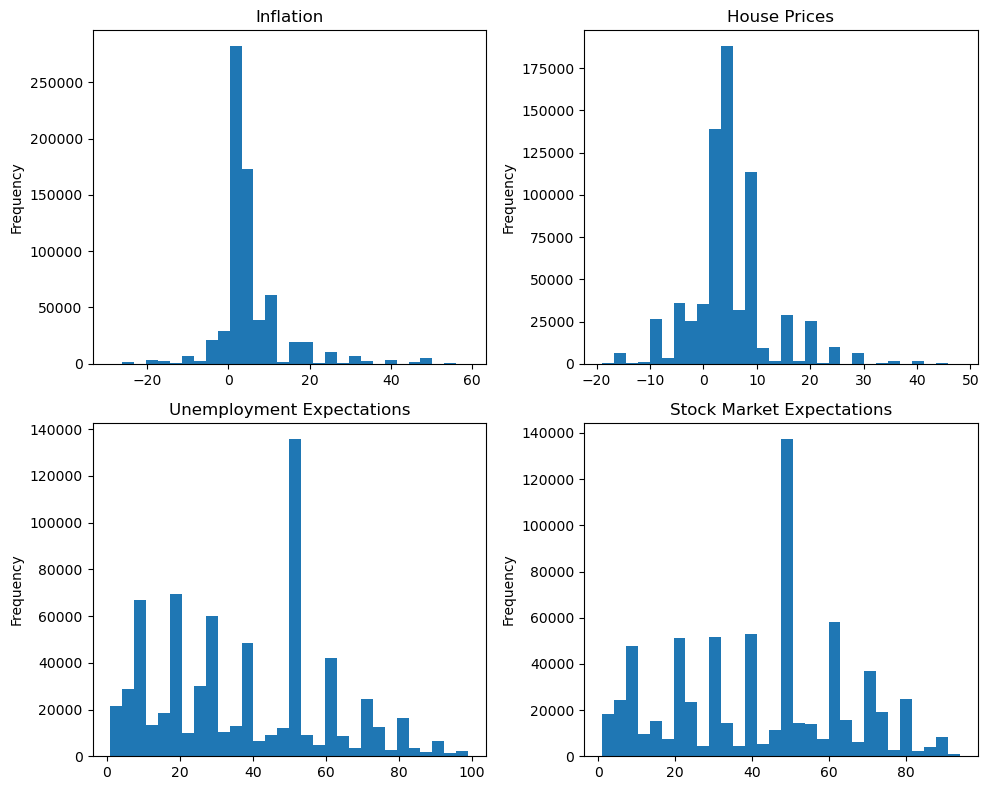

In [19]:
# titles
titles = {
    "infl_1y": "Inflation",
    "house_price_change": "House Prices",
    "prob_unrate_up": "Unemployment Expectations",
    "prob_stocks_up": "Stock Market Expectations"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# plot
for i, var in enumerate(variables):
    axes[i].hist(df[var], bins=30)
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")  # remove variable name on x-axis
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The histograms show that most households expect low inflation and positive house price growth, although there are some extreme values. Expectations about unemployment and the stock market are spread between 0 and 100, but many responses are clustered around 50, indicating uncertainty. 

## 2. Average expectations over time


In [20]:
# group by month and take mean
df_grouped = df.groupby("year_month")[variables].mean()

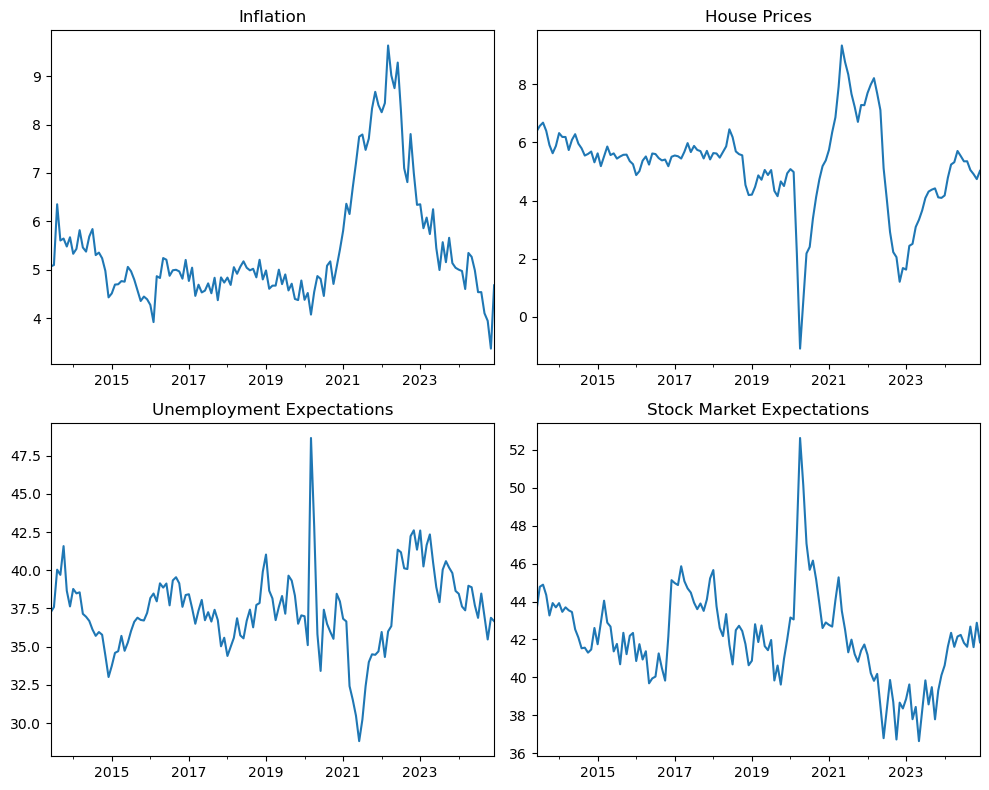

In [21]:
# titles
titles = {
    "infl_1y": "Inflation",
    "house_price_change": "House Prices",
    "prob_unrate_up": "Unemployment Expectations",
    "prob_stocks_up": "Stock Market Expectations"
}

# plot 
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    df_grouped[var].plot(ax=axes[i])
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")  # cleaner
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

The time series show that inflation expectations (infl_1y) were relatively stable before increasing sharply around 2021–2022, followed by a decline. This likely reflects changing macroeconomic conditions during this period.

House price expectations (house_price_change) display more volatility, with a strong drop around 2020 and a sharp increase afterward, before stabilizing again.

The probability of higher unemployment (prob_unrate_up) fluctuates over time, with noticeable spikes during periods of economic uncertainty, suggesting that households adjust expectations in response to shocks.

Similarly, expectations about stock market increases (prob_stocks_up) vary over time, with a clear peak around 2020–2021 and a decline afterward, indicating changing sentiment in financial markets.

## 3. Share of optimistic households

In [22]:
# grouping by month and calculating mean for the two selected variables
optimist_vars = ["optimist_unrate", "optimist_stocks", "optimist_house_price"]

df_opt = df.groupby("year_month")[optimist_vars].mean()

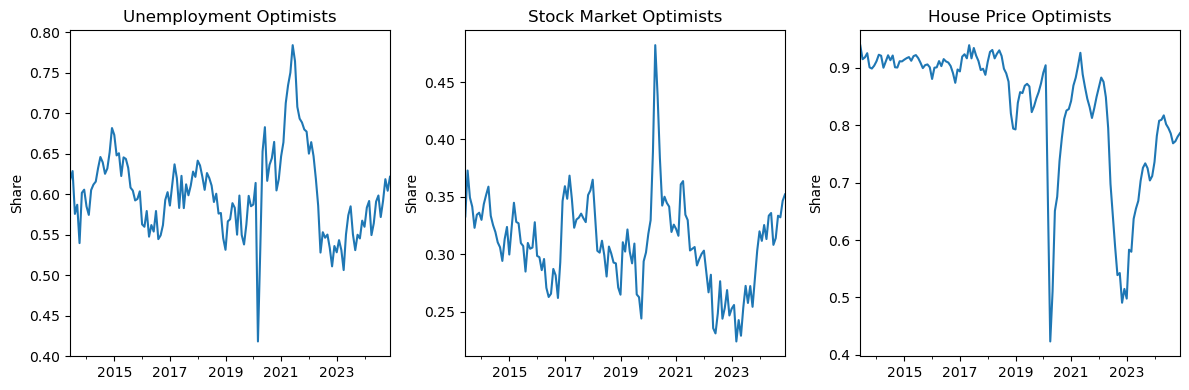

In [23]:
# titles
titles = {
    "optimist_unrate": "Unemployment Optimists",
    "optimist_stocks": "Stock Market Optimists",
    "optimist_house_price": "House Price Optimists"
}

# plot 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

for i, var in enumerate(optimist_vars):
    df_opt[var].plot(ax=axes[i])
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Share")

plt.tight_layout()
plt.show()

The share of optimistic households fluctuates over time across all three measures, with noticeable variation around key macroeconomic periods. This indicates that expectations are sensitive to economic conditions.

All three series display similar dynamics, suggesting that optimism about unemployment, the stock market, and house prices tends to move together over time.

# Task 4 - Exploratory data analysis (macro/finance)

In task 4 we examine how macroeconomic variables help explain household expectations. Again, we use lagged macro variables to avoid look ahead bias

## 1. Figure showing the time series of the original variables in levels

In [24]:
macro_vars = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]

df_levels = df.groupby("year_month")[macro_vars].mean(numeric_only=True)

# standardize to fit in one model
df_levels_std = (df_levels - df_levels.mean()) / df_levels.std()

<Figure size 10000x5000 with 0 Axes>

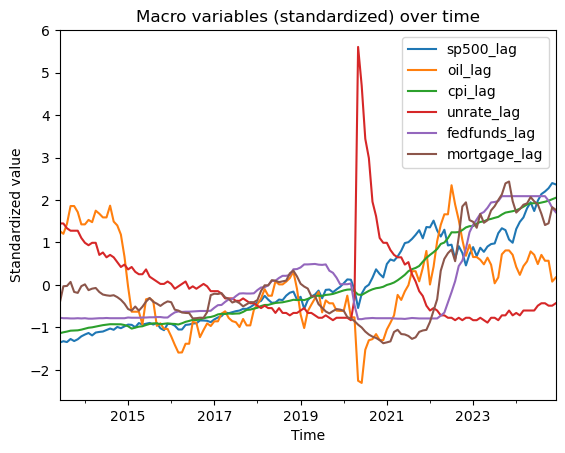

In [25]:
# plot
plt.figure(figsize=(100, 50)) 
df_levels_std.plot()
plt.title("Macro variables (standardized) over time")
plt.xlabel("Time")
plt.ylabel("Standardized value")
plt.show()

The standardized level plot shows the evolution of macroeconomic variables over time while allowing for better comparison across series with different scales. The S&P 500 exhibits a strong upward trend, while variables such as inflation, unemployment, and interest rates remain relatively stable. Standardization makes it easier to compare movements across variables that would otherwise differ significantly in magnitude.

## 2. Changes in macro variables

In [26]:
# create month-over-month change variables
sp500["sp500_change"] = sp500["sp500"].diff()
oil["oil_change"] = oil["oil"].diff()
cpi["cpi_change"] = cpi["cpi"].diff()
unrate["unrate_change"] = unrate["unrate"].diff()
fedfunds["fedfunds_change"] = fedfunds["fedfunds"].diff()
mortgage["mortgage_change"] = mortgage["mortgage"].diff()

# merge change variables into df
df = df.merge(sp500[["year_month", "sp500_change"]], on="year_month", how="left")
df = df.merge(oil[["year_month", "oil_change"]], on="year_month", how="left")
df = df.merge(cpi[["year_month", "cpi_change"]], on="year_month", how="left")
df = df.merge(unrate[["year_month", "unrate_change"]], on="year_month", how="left")
df = df.merge(fedfunds[["year_month", "fedfunds_change"]], on="year_month", how="left")
df = df.merge(mortgage[["year_month", "mortgage_change"]], on="year_month", how="left")

In [27]:
macro_changes = ["sp500_change", "oil_change", "cpi_change", "unrate_change", "fedfunds_change", "mortgage_change"]

df_changes = df.groupby("year_month")[macro_changes].mean(numeric_only=True)

df_changes_std = (df_changes - df_changes.mean()) / df_changes.std()

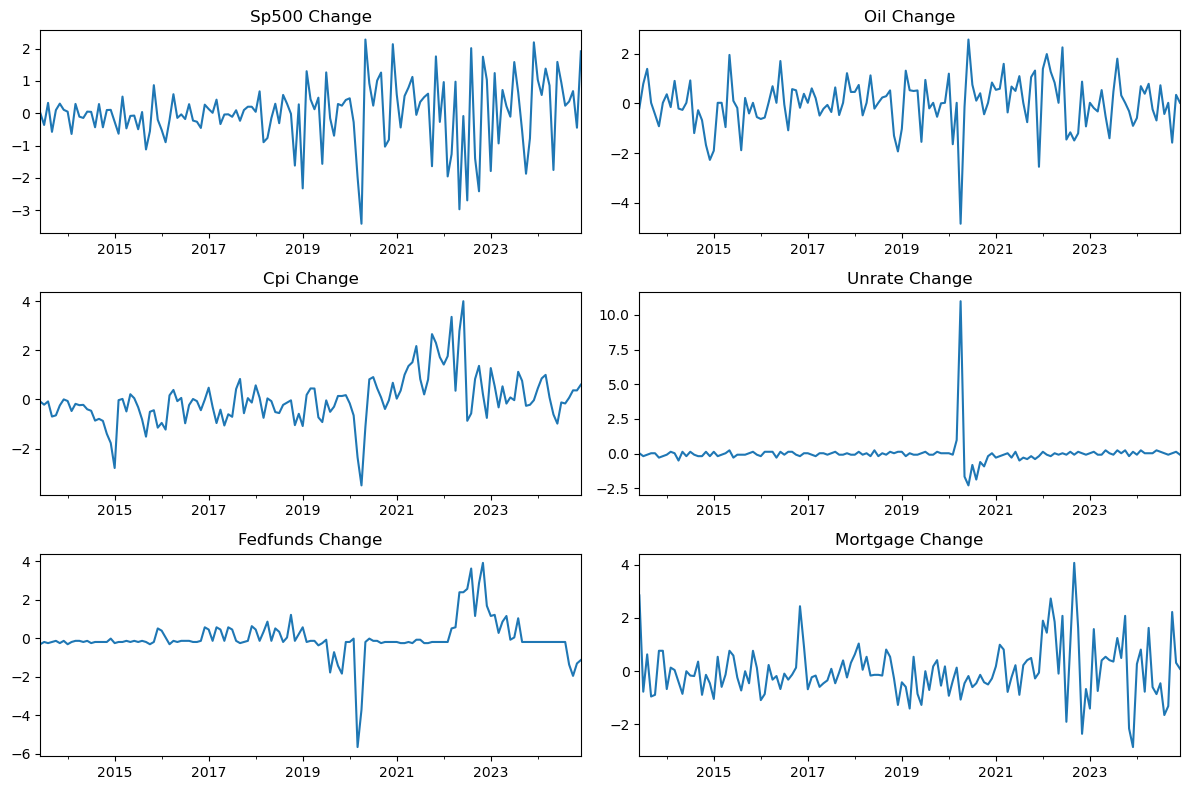

In [28]:
# plot
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(macro_changes):
    df_changes_std[var].plot(ax=axes[i])
    axes[i].set_title(var.replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Correlation between macro varaibles and expectation variables

In [29]:
expectation_vars = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

macro_all = macro_vars + macro_changes

In [30]:
# table
for var in expectation_vars:
    
    corr = df[macro_all + [var]].corr()[var].drop(var)
    corr = corr.sort_values(key=abs, ascending=False)  # viktig!
    
    corr_table = corr.to_frame(name="Correlation")
    
    print(f"\nCorrelation with {var}:")
    display(corr_table.round(3))


Correlation with infl_1y:


,Correlation
cpi_change,0.093
oil_lag,0.066
fedfunds_change,0.060
sp500_lag,0.057
cpi_lag,0.046
oil_change,0.026
mortgage_change,0.026
fedfunds_lag,-0.025
sp500_change,-0.013
unrate_change,-0.011



Correlation with house_price_change:


,Correlation
fedfunds_lag,-0.082
mortgage_lag,-0.073
cpi_change,0.065
oil_change,0.062
unrate_change,-0.060
cpi_lag,-0.054
oil_lag,0.024
sp500_change,0.020
sp500_lag,-0.015
mortgage_change,0.013



Correlation with prob_unrate_up:


,Correlation
mortgage_lag,0.054
fedfunds_lag,0.044
unrate_change,0.032
unrate_lag,-0.030
sp500_change,-0.030
cpi_lag,0.025
cpi_change,-0.023
oil_lag,0.021
oil_change,-0.014
fedfunds_change,0.009



Correlation with prob_stocks_up:


,Correlation
unrate_lag,0.056
mortgage_lag,-0.050
cpi_lag,-0.049
fedfunds_change,-0.047
fedfunds_lag,-0.043
sp500_lag,-0.039
cpi_change,-0.034
oil_lag,-0.034
unrate_change,0.029
mortgage_change,-0.010


The correlations between macro variables and expectations are generally very small, suggesting limited explanatory power. A few weak patterns emerge: inflation expectations (infl_1y) are slightly positively correlated with oil prices and stock market levels, while house price expectations are weakly negatively related to interest rates (fed funds and mortgage rates). Overall, the results indicate that individual expectations are only weakly related to aggregate macroeconomic conditions.

# Part 5 - Predicting continuous expectation variables

We split the data into a training sample (before 2024) and a test sample (2024). Thereafter, estimate Linear Regression, Ridge, and Lasso models using macroeconomic variables. The models are then extanded to include individual variables.  

## 1. Split data

In [31]:
df_train = df[df["date"] < "2024-01-01"]
df_test  = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")]

print(f"Training observations: {len(df_train)}")
print(f"Test observations: {len(df_test)}")

Training observations: 2831833
Test observations: 224042


## 2. Define varaibles

In [32]:
# target variable
y_var = "infl_1y"

# macro features
X_macro = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]

# individual features
X_extra = ["age_init", "educ", "hh_inc_bin", "female"]

# selected individual variables 
num_features = X_macro + ["age_init"]
cat_features = ["educ", "female"]

## Part A - Macro variables only

In [33]:
# prepare data
X_vars = num_features + cat_features

train = df_train[X_vars + [y_var, "year_month"]].dropna().copy()
test  = df_test[X_vars + [y_var, "year_month"]].dropna().copy()

X_train = train[X_vars]
y_train = train[y_var]

X_test = test[X_vars]
y_test = test[y_var]

In [34]:
#
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

NameError: name 'ColumnTransformer' is not defined

### Linear regression

In [ ]:
lin_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

In [ ]:
# print
print("Linear Regression:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print("R2:", r2_score(y_test, y_pred_lin))

Linear Regression:
RMSE: 9.28148251191444
R2: -0.0026393567540277107


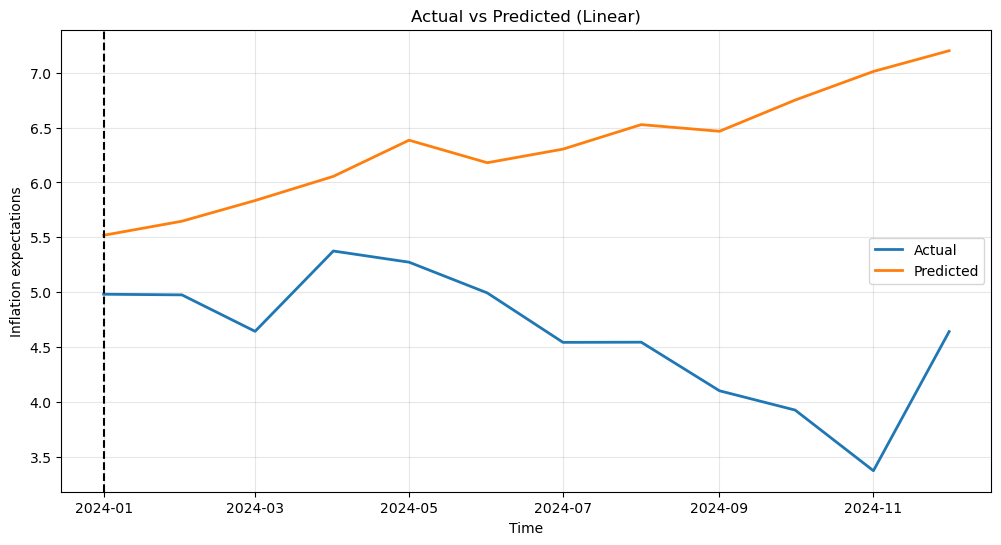

In [ ]:
# predictions
test["pred"] = y_pred_lin

df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()
df_plot.index = df_plot.index.to_timestamp()

plt.figure(figsize=(12,6))

plt.plot(df_plot.index, df_plot[y_var], label="Actual", linewidth=2)
plt.plot(df_plot.index, df_plot["pred"], label="Predicted", linewidth=2)

plt.axvline(x=pd.Timestamp("2024-01-01"), linestyle="--", color="black")

plt.title("Actual vs Predicted (Linear)")
plt.xlabel("Time")
plt.ylabel("Inflation expectations")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Rigide regression

In [ ]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 20)

ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RidgeCV(alphas=alphas, cv=5))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [ ]:
# print
print("Ridge Regression:")
print("Best alpha:", ridge_model.named_steps["model"].alpha_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2:", r2_score(y_test, y_pred_ridge))

Ridge Regression:
Best alpha: 1000.0
RMSE: 9.280735105103785
R2: -0.002477884853306911


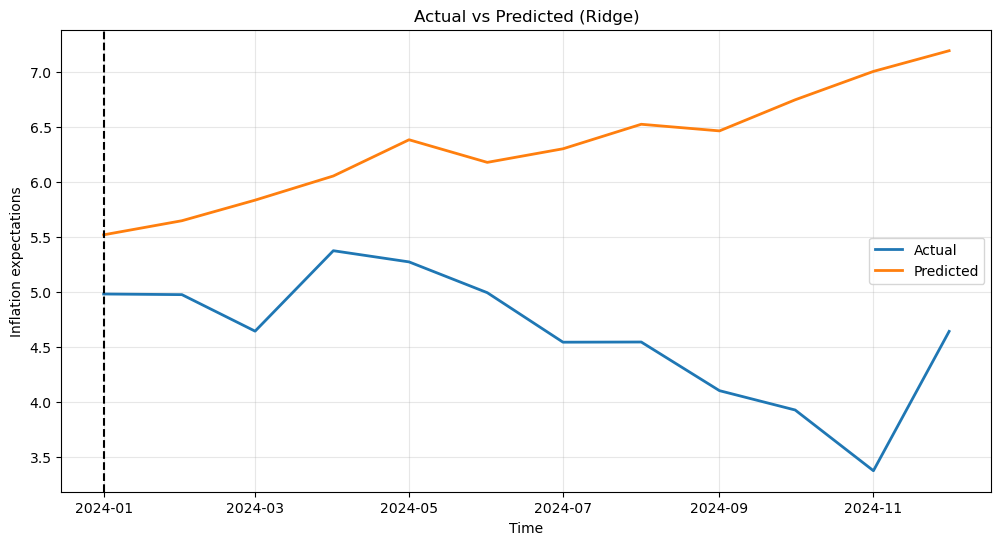

In [ ]:
# predictions
test["pred"] = y_pred_ridge

df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()
df_plot.index = df_plot.index.to_timestamp()

plt.figure(figsize=(12,6))

plt.plot(df_plot.index, df_plot[y_var], label="Actual", linewidth=2)
plt.plot(df_plot.index, df_plot["pred"], label="Predicted", linewidth=2)

plt.axvline(x=pd.Timestamp("2024-01-01"), linestyle="--", color="black")

plt.title("Actual vs Predicted (Ridge)")
plt.xlabel("Time")
plt.ylabel("Inflation expectations")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

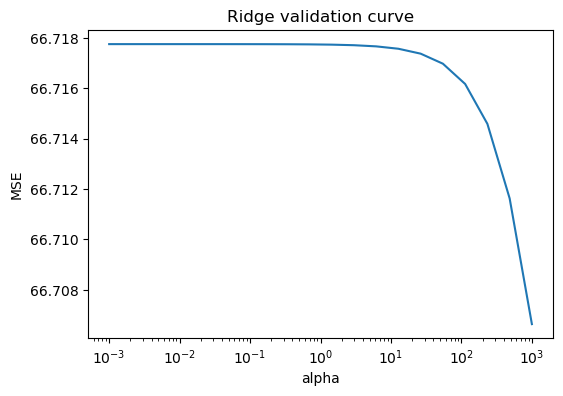

In [ ]:
# validation curve for ridge
from sklearn.linear_model import Ridge
from sklearn.model_selection import validation_curve

alphas = np.logspace(-3, 3, 20)

train_scores, val_scores = validation_curve(
    Ridge(),
    preprocessor.fit_transform(X_train),
    y_train,
    param_name="alpha",         
    param_range=alphas,        
    scoring="neg_mean_squared_error",
    cv=5
)

plt.figure(figsize=(6,4))
plt.plot(alphas, -val_scores.mean(axis=1))
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("Ridge validation curve")
plt.show()

### Lasso regression

Lasso adds an L1 penalty and can shrink coefficients to zero, performing automatic variable selection.

In [ ]:
lasso_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LassoCV(cv=5))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

In [ ]:
# print
print("Lasso Regression:")
print("Best alpha:", lasso_model.named_steps["model"].alpha_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2:", r2_score(y_test, y_pred_lasso))

Lasso Regression:
Best alpha: 0.0027623738970726933
RMSE: 9.280506659713883
R2: -0.002428533453849635


## Plot for predictions

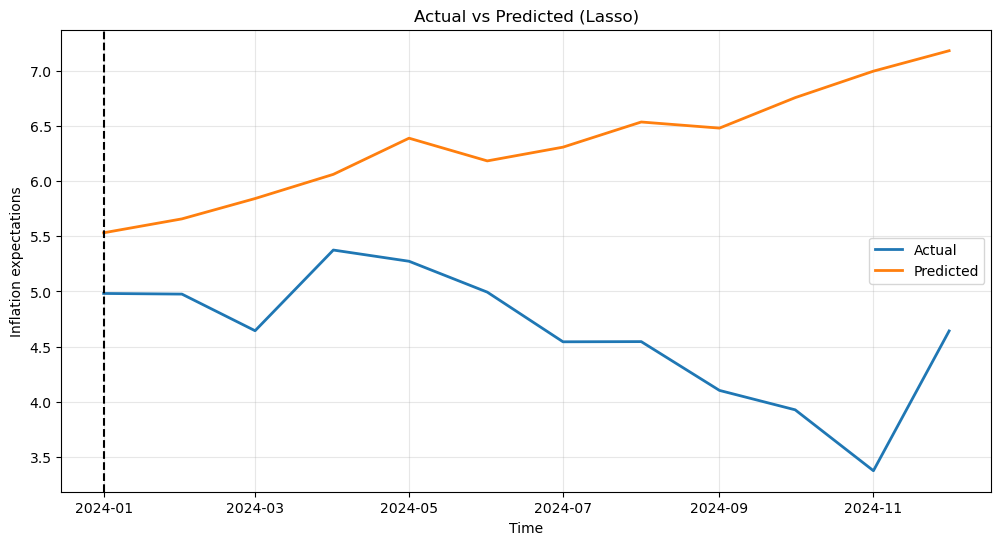

In [ ]:
# predictions
test["pred"] = y_pred_lasso


df_plot.index = df_plot.index.to_timestamp()

plt.figure(figsize=(12,6))

plt.plot(df_plot.index, df_plot[y_var], label="Actual", linewidth=2)
plt.plot(df_plot.index, df_plot["pred"], label="Predicted", linewidth=2)

plt.axvline(x=pd.Timestamp("2024-01-01"), linestyle="--", color="black")

plt.title("Actual vs Predicted (Lasso)")
plt.xlabel("Time")
plt.ylabel("Inflation expectations")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Part B - Macro and individual variables

In [37]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# continuous individual variables
cont_individual = ["age_init"]

# categorical individual variables (should not be treated as continuous)
cat_individual = ["educ", "hh_inc_bin", "female"]

# all features
X_vars_b = X_macro + cont_individual + cat_individual

In [38]:
# prepare data
train_b = df_train[X_vars_b + [y_var, "year_month"]].dropna().copy()
test_b  = df_test[X_vars_b  + [y_var, "year_month"]].dropna().copy()

X_train_b = train_b[X_vars_b]
y_train_b  = train_b[y_var]

X_test_b  = test_b[X_vars_b]
y_test_b   = test_b[y_var]

In [39]:
# preprocessor: scale continuous, one-hot encode categorical
preprocessor = ColumnTransformer(transformers=[
    ("cont", StandardScaler(), X_macro + cont_individual),
    ("cat",  OneHotEncoder(drop="first", sparse_output=False), cat_individual)
])

In [40]:
# Ridge with macro + individual features
alphas = np.logspace(-3, 3, 20)

ridge_b = Pipeline([
    ("prep",   preprocessor),
    ("model",  RidgeCV(alphas=alphas, cv=5))
])

ridge_b.fit(X_train_b, y_train_b)

y_train_pred_b = ridge_b.predict(X_train_b)
y_test_pred_b  = ridge_b.predict(X_test_b)

print("Ridge (Macro + Individual):")
print("Best alpha:", ridge_b.named_steps["model"].alpha_)
print("Train RMSE:", np.sqrt(mean_squared_error(y_train_b, y_train_pred_b)))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test_b,  y_test_pred_b)))
print("Train R2:",   r2_score(y_train_b, y_train_pred_b))
print("Test  R2:",   r2_score(y_test_b,  y_test_pred_b))

Ridge (Macro + Individual):
Best alpha: 1000.0
Train RMSE: 8.0773270040417
Test  RMSE: 9.256158822013461
Train R2: 0.07410839331208441
Test  R2: 0.004072847533787449


In [41]:
# Lasso with macro + individual features
lasso_b = Pipeline([
    ("prep",  preprocessor),
    ("model", LassoCV(cv=5))
])

lasso_b.fit(X_train_b, y_train_b)

y_train_pred_b = lasso_b.predict(X_train_b)
y_test_pred_b  = lasso_b.predict(X_test_b)

print("Lasso (Macro + Individual):")
print("Best alpha:", lasso_b.named_steps["model"].alpha_)
print("Train RMSE:", np.sqrt(mean_squared_error(y_train_b, y_train_pred_b)))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test_b,  y_test_pred_b)))
print("Train R2:",   r2_score(y_train_b, y_train_pred_b))
print("Test  R2:",   r2_score(y_test_b,  y_test_pred_b))

Lasso (Macro + Individual):
Best alpha: 0.0019524683891726355
Train RMSE: 8.07822237432961
Test  RMSE: 9.255193235627912
Train R2: 0.07390311208918288
Test  R2: 0.004280623471709433


<Figure size 640x480 with 0 Axes>

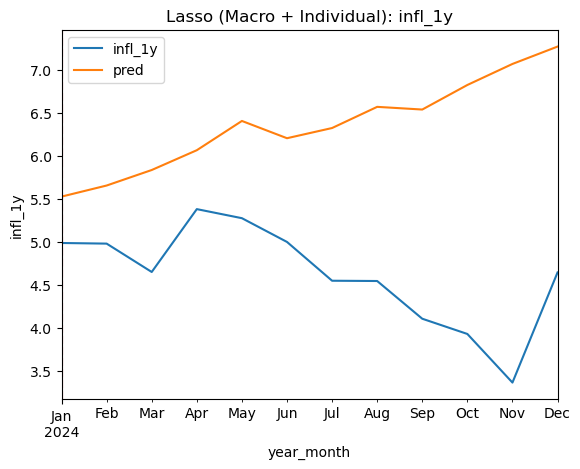

In [42]:
# plot actual vs predicted
test_b["pred"] = y_test_pred_b

df_plot = test_b.groupby("year_month")[[y_var, "pred"]].mean()

plt.figure()
df_plot.plot()
plt.axvline(x="2024-01", color="red", linestyle="--")
plt.title(f"Lasso (Macro + Individual): {y_var}")
plt.ylabel(y_var)
plt.show()

# Part 6 - Predicting binary optimism variables

In this part, we predict binary optimism variables using classification models. We use logistic regression and random forest, and evaluate performance using accuracy metrics

## Defining variables

In [50]:
# skal til start
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

In [51]:
# target and features
y_var   = "optimist_unrate"
X_macro = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]
X_extra = ["age_init", "educ", "hh_inc_bin", "female"]

## Part A - Macro only

In [52]:
# prepare data
train = df_train[X_macro + [y_var, "year_month"]].dropna().copy()
test  = df_test[X_macro  + [y_var, "year_month"]].dropna().copy()

X_train = train[X_macro]
y_train = train[y_var]

X_test = test[X_macro]
y_test = test[y_var]

In [ ]:
# logistic regression
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

logit.fit(X_train, y_train)
y_pred = logit.predict(X_test)

print("Logistic Regression (macro only):")
print(f"  Accuracy:          {accuracy_score(y_test, y_pred):.3f}")
print(f"  Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print(f"  Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")


/opt/anaconda3/envs/FIE463/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/opt/anaconda3/envs/FIE463/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/anaconda3/envs/FIE463/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attri

Logistic Regression L2 (macro only):
  Best C:            0.0379
  Accuracy:          0.526
  Balanced accuracy: 0.507
  Confusion matrix:
[[36742 55958]
 [50206 81136]]


<Figure size 640x480 with 0 Axes>

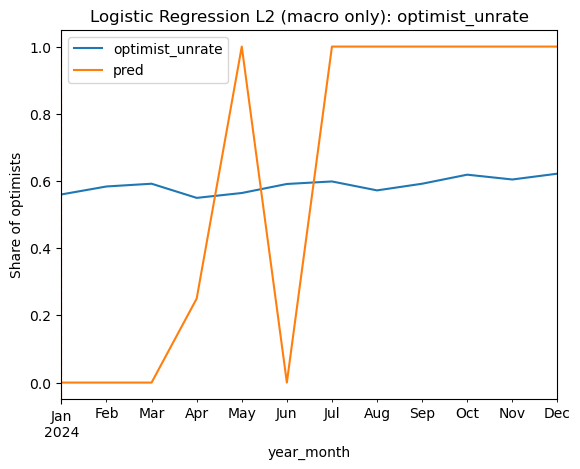

In [ ]:
# plot actual vs predicted fraction of optimists
test["pred"] = y_pred
df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()

plt.figure()
df_plot.plot()
plt.axvline(x="2024-01", color="red", linestyle="--")
plt.title(f"Logistic Regression (macro only): {y_var}")
plt.ylabel("Share of optimists")
plt.show()

## Part B - Makro and individual varaibles

In [56]:
# new features
X_vars = X_macro + X_extra

train = df_train[X_vars + [y_var, "year_month"]].dropna().copy()
test  = df_test[X_vars  + [y_var, "year_month"]].dropna().copy()

X_train = train[X_vars]
y_train = train[y_var]
X_test  = test[X_vars]
y_test  = test[y_var]

In [57]:
# logistic regression L2 with macro + individual features
logit_b = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

logit_b.fit(X_train, y_train)
y_pred_b = logit_b.predict(X_test)

print("Logistic Regression (macro + individual):")
print(f"  Accuracy:          {accuracy_score(y_test, y_pred_b):.3f}")
print(f"  Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_b):.3f}")
print(f"  Confusion matrix:\n{confusion_matrix(y_test, y_pred_b)}")

Logistic Regression (macro + individual):
  Accuracy:          0.554
  Balanced accuracy: 0.535
  Confusion matrix:
[[38980 52888]
 [46110 83791]]


<Figure size 640x480 with 0 Axes>

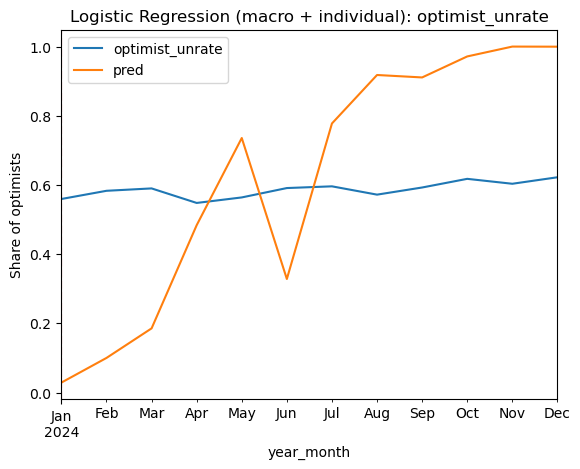

In [ ]:
# plot
test["pred"] = y_pred_b
df_plot = test.groupby("year_month")[[y_var, "pred"]].mean()

plt.figure()
df_plot.plot()
plt.axvline(x="2024-01", color="red", linestyle="--")
plt.title(f"Logistic Regression (macro + individual): {y_var}")
plt.ylabel("Share of optimists")
plt.show()

# Part 7 -  Conclusion